In [1]:
import time
import numpy as np
from estimators.volt_funcs_mod import Volterra
from estimators.ngrc_funcs import NGRC
from estimators.polykernel_funcs import PolynomialKernel

from datagen.data_generate_dde import dde_rk45
from utils.normalisation import normalise_arrays
from utils.plotting import plot_data, plot_data_distributions
from utils.errors import calculate_mse, calculate_nmse, calculate_mae, calculate_mdae_err, calculate_r2_err, calculate_mape_err
from utils.errors import calculate_wasserstein1err, calculate_specdens_periodogram_err, calculate_specdens_welch_err
from utils.errors import valid_pred_time
from systems.ddes import mackeyglass

from prettytable import PrettyTable

import matplotlib.pyplot as plt
import h5py
from itertools import product
import multiprocessing


In [4]:
#%% 
# Generate dataset

SYSTEM = 'TFIM'
STATE = 'Neel'
BC      = "periodic"  # 'open' or 'periodic'
if BC == 'periodic':
    SYSTEM += f'_{BC}'
N = 10
hx = 0.8
real = 0
dynamics_type = 'sz_all' # 'sz_dynamics', 'sz_all', 'szsz_all'

# Load data from npy files
data_rawraw = np.load(f'data/{SYSTEM}_{dynamics_type}_N{N}_hx{hx}_{STATE}_{real}.npy')
if data_rawraw.ndim == 1:
    data_raw = np.expand_dims(data_rawraw, axis=1)
    ndim = 1
else:
    data_raw = data_rawraw.T
    ndim = data_raw.shape[1]
# entropy_dynamics = np.load(f'data/{SYSTEM}_sent_N{N}_hx{hx}_real{real}.npy')
tgrid_raw = np.load(f'data/{SYSTEM}_tgrid.npy')

delta_t = tgrid_raw[1] - tgrid_raw[0]

# Define training and washout size
t_train = 300
ntrain = int(t_train / delta_t)
t_wash = 50
wash = int(t_wash / delta_t)
data = data_raw[wash:] # Ensure data is long enough for training + washout
tgrid = tgrid_raw[wash:]
washout = 0

# Define input hyperparameters for Volterra
ld_coef, tau_coef, reg_best, washout, selected_index = 0.9981766519991315,0.00044892512582186077,0.001, 0, [N//2]

# Construct training input and teacher, testing input and teacher
training_input_orig = data[0:ntrain-1] 
training_teacher_orig = data[1:ntrain]

ndata = len(data)
# ntrain = 500
t_test = 100
ntest = int(t_test / delta_t)
# ntest = ndata - ntrain
# Max valid prediction time is about above 10. Round to 11 for error range.
t_err = 50
err_range = int(t_err / delta_t)
# Construct training input and teacher, testing input and teacher
training_input_orig = data[0:ntrain-1] 
training_teacher_orig = data[1:ntrain]
testing_input_orig = data[ntrain-1:ntrain+ntest-1]
testing_teacher_orig = data[ntrain:ntrain+ntest]
x_values = tgrid[ntrain:ntrain+ntest]
# Define Lyapunov exponent and x_ranges for plotting   
# lyapunov_exponent = 0.005
# x_values = [index * lyapunov_exponent * 1 for index in range(len(testing_teacher_orig))]

# %% 
# Volterra with L2 least squares regression

# Normalise the arrays for Volterra
normalisation_output = normalise_arrays([training_input_orig, training_teacher_orig, testing_input_orig, testing_teacher_orig], norm_type="ScaleL2Shift")
train_input_volt, train_teacher_volt, test_input_volt, test_teacher_volt = normalisation_output[0]
# Print shapes to check they are correct
print(f"Train input shape: {train_input_volt.shape}")
print(f"Train teacher shape: {train_teacher_volt.shape}")
print(f"Test input shape: {test_input_volt.shape}")
print(f"Test teacher shape: {test_teacher_volt.shape}")

shift_volt, scale_volt = normalisation_output[1], normalisation_output[2]



# Start timer
start = time.time()

# Run Volterra as a class
# Tune reg to get the best results around given reg in log space
# log_reg = np.log10(reg_best)
# reg_range = np.logspace(log_reg - 2, log_reg + 2, num=21)
# min_mse = float('inf')
# best_reg = None
# for reg in reg_range:
#     volt = Volterra(ld_coef, tau_coef, reg, washout, selected_index)
#     output_volt = volt.Train(train_input_volt, train_teacher_volt).PathContinue(train_teacher_volt[-1], test_teacher_volt.shape[0])
#     mse_volt = calculate_mse(test_teacher_volt[0:err_range], output_volt[0:err_range], shift_volt, scale_volt)
#     if mse_volt < min_mse:
#         min_mse = mse_volt
#         best_reg = reg

# # print shapes to check they are correct
# print(f"Output shape: {output_volt.shape}")
# print(f"Best regularization parameter: {best_reg}")
# print(f"Minimum MSE: {min_mse}")
# Print time taken for training and generating outputs
# print(f"Volterra took: {time.time() - start}")

volt = Volterra(ld_coef, tau_coef, reg_best, washout, selected_index)
output_volt = volt.Train(train_input_volt, train_teacher_volt).PathContinue(train_teacher_volt[-1], test_teacher_volt.shape[0])

Train input shape: (5999, 10)
Train teacher shape: (5999, 10)
Test input shape: (2000, 10)
Test teacher shape: (2000, 10)


y_true shape:  (2000, 10)
+----------+
| Volterra |
+----------+
|    30    |
+----------+


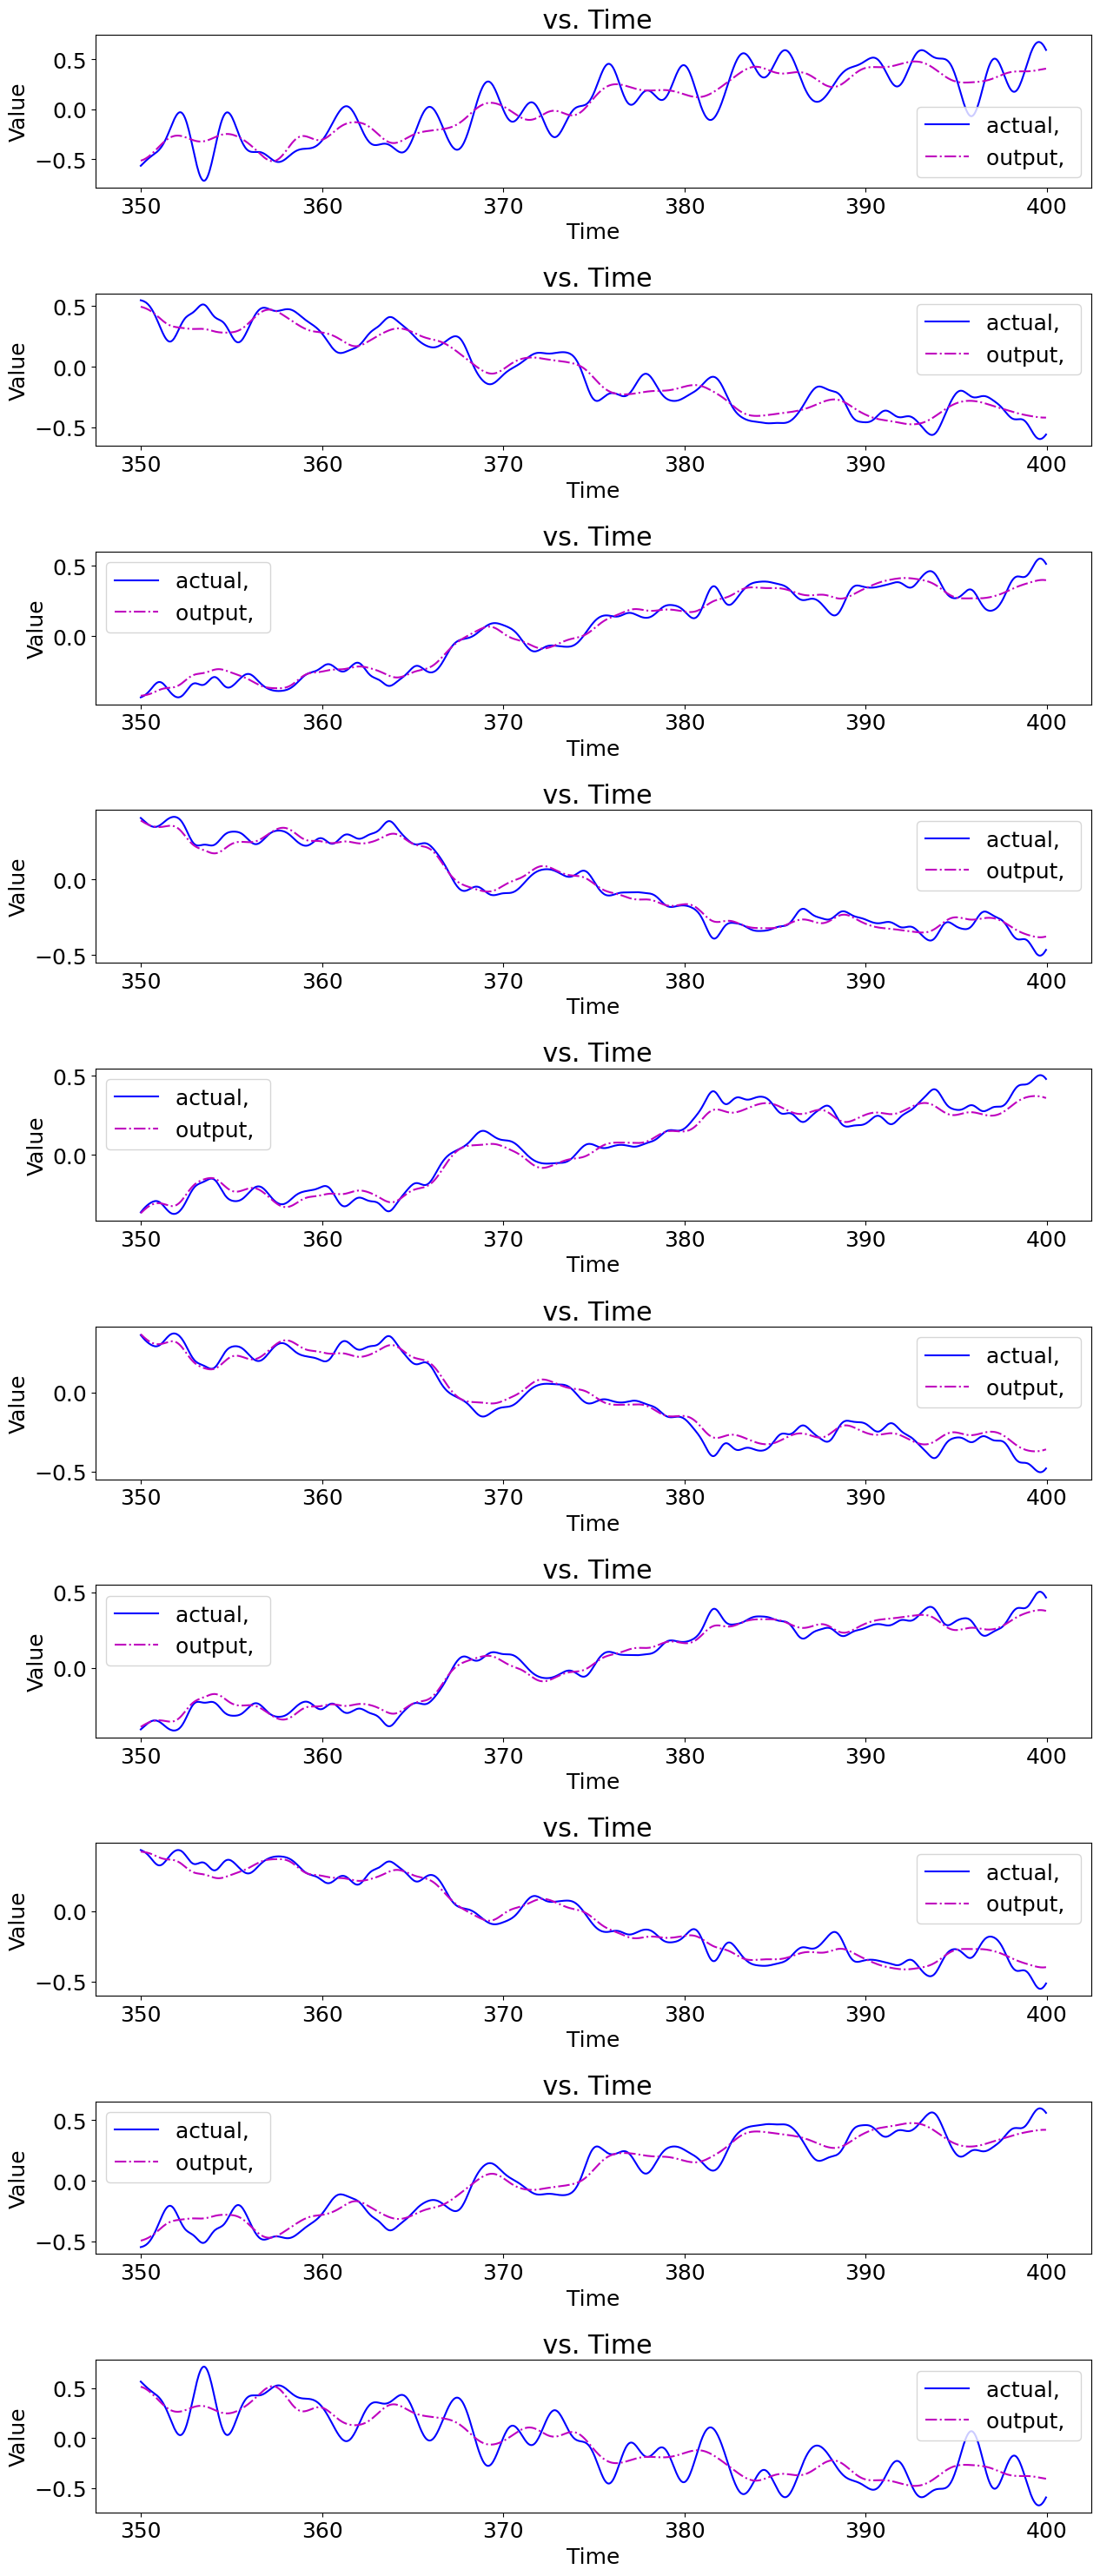

+----------+-----------------------+---------------------+----------------------+----------------------+--------------------+--------------------+
|  Method  |          MSE          |    Normalised MSE   |         MdAE         |         MAE          |        MAPE        |      R2-score      |
+----------+-----------------------+---------------------+----------------------+----------------------+--------------------+--------------------+
| Volterra | 0.0066551153258140655 | 0.06626103792549622 | 0.052870951171349344 | 0.059094129530599324 | 0.6227121126866753 | 0.9337389620745038 |
+----------+-----------------------+---------------------+----------------------+----------------------+--------------------+--------------------+


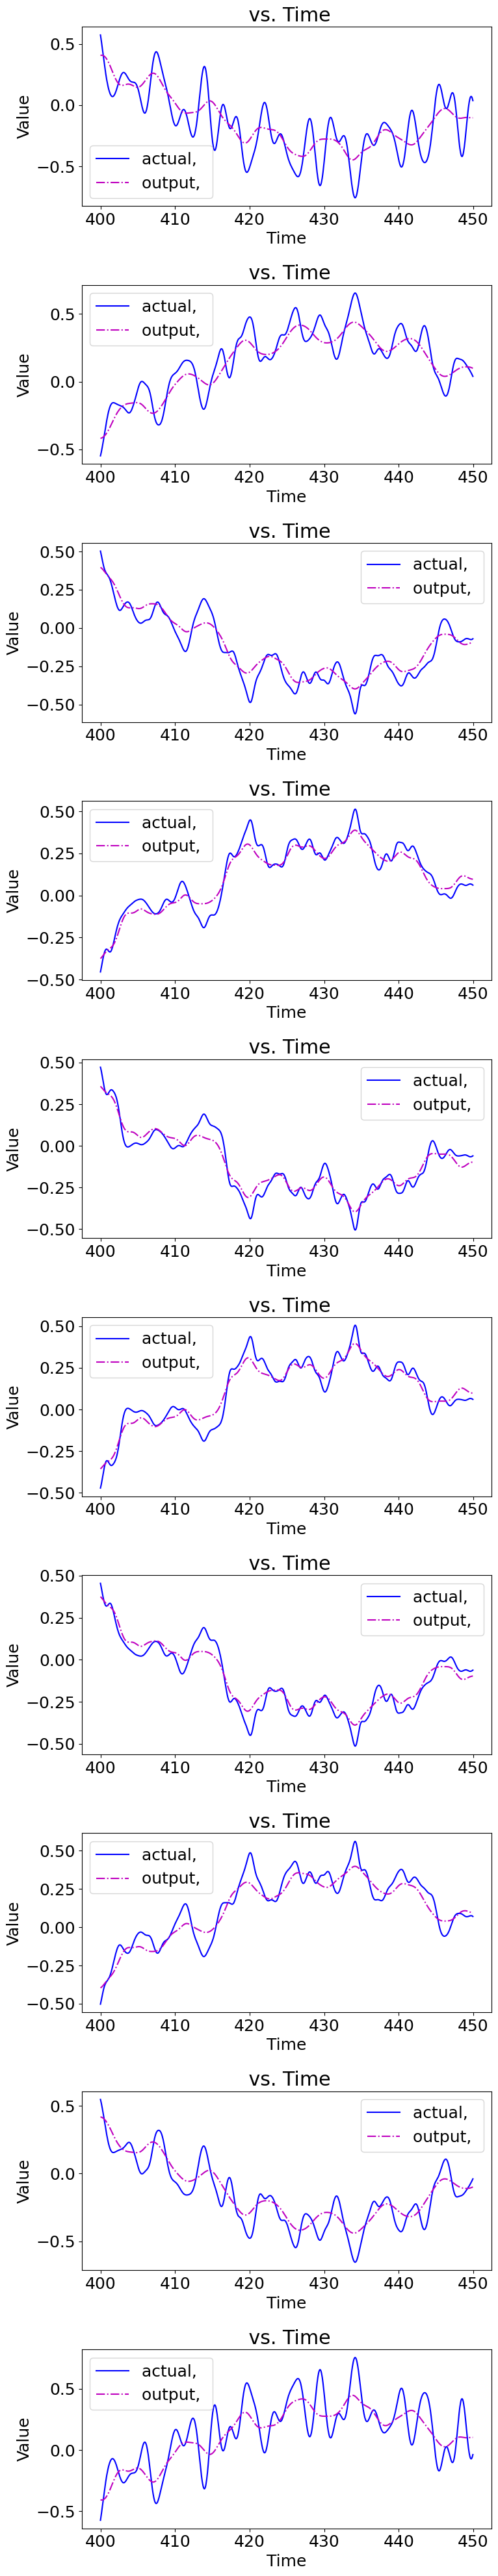

In [5]:
epsilon = 0.2
valid_pred_time_volt = valid_pred_time(test_teacher_volt, output_volt, shift_volt, scale_volt)
# valid_pred_time_poly = valid_pred_time(test_teacher_poly, output_poly, shift_poly, scale_poly) * 1 * lyapunov_exponent
# valid_pred_time_ngrc = valid_pred_time(test_teacher_ngrc, output_ngrc, shift_ngrc, scale_ngrc) * 1 * lyapunov_exponent

# Print valid prediction times
# valid_pred_time_table = PrettyTable(["Volterra", "Polynomial", "NG-RC"])
# valid_pred_time_table.add_row([valid_pred_time_volt, valid_pred_time_poly, valid_pred_time_ngrc])
# print(valid_pred_time_table)
valid_pred_time_table = PrettyTable(["Volterra"])
valid_pred_time_table.add_row([valid_pred_time_volt])
print(valid_pred_time_table)
# %% 
# Calculate time step by time step errors



# Volterra
mse_volt = calculate_mse(test_teacher_volt[0:err_range], output_volt[0:err_range], shift_volt, scale_volt)
nmse_volt = calculate_nmse(test_teacher_volt[0:err_range], output_volt[0:err_range], shift_volt, scale_volt)
mdae_volt = calculate_mdae_err(test_teacher_volt[0:err_range], output_volt[0:err_range], shift_volt, scale_volt)
mae_volt = calculate_mae(test_teacher_volt[0:err_range], output_volt[0:err_range], shift_volt, scale_volt)
mape_volt = calculate_mape_err(test_teacher_volt[0:err_range], output_volt[0:err_range], shift_volt, scale_volt)
r2_volt = calculate_r2_err(test_teacher_volt[0:err_range], output_volt[0:err_range], shift_volt, scale_volt)

# # Polynomial 
# mse_poly = calculate_mse(test_teacher_poly[0:err_range], output_poly[0:err_range], shift_poly, scale_poly)
# nmse_poly = calculate_nmse(test_teacher_poly[0:err_range], output_poly[0:err_range], shift_poly, scale_poly)
# mdae_poly = calculate_mdae_err(test_teacher_poly[0:err_range], output_poly[0:err_range], shift_poly, scale_poly)
# mae_poly = calculate_mae(test_teacher_poly[0:err_range], output_poly[0:err_range], shift_poly, scale_poly)
# mape_poly = calculate_mape_err(test_teacher_poly[0:err_range], output_poly[0:err_range], shift_poly, scale_poly)
# r2_poly = calculate_r2_err(test_teacher_poly[0:err_range], output_poly[0:err_range], shift_poly, scale_poly)

# # NG-RC
# mse_ngrc = calculate_mse(test_teacher_ngrc[0:err_range], output_ngrc[0:err_range], shift_ngrc, scale_ngrc)
# nmse_ngrc = calculate_nmse(test_teacher_ngrc[0:err_range], output_ngrc[0:err_range], shift_ngrc, scale_ngrc)
# mdae_ngrc = calculate_mdae_err(test_teacher_ngrc[0:err_range], output_ngrc[0:err_range], shift_ngrc, scale_ngrc)
# mae_ngrc = calculate_mae(test_teacher_ngrc[0:err_range], output_ngrc[0:err_range], shift_ngrc, scale_ngrc)
# mape_ngrc = calculate_mape_err(test_teacher_ngrc[0:err_range], output_ngrc[0:err_range], shift_ngrc, scale_ngrc)
# r2_ngrc = calculate_r2_err(test_teacher_ngrc[0:err_range], output_ngrc[0:err_range], shift_ngrc, scale_ngrc)

# %%
# Plot time signals up to err_range

plot_data([test_teacher_volt[0:err_range], output_volt[0:err_range]], shift=shift_volt, scale=scale_volt, filename=f"images/{SYSTEM}_volt.pdf", figsize=(13, 3), xlabel=['']*ndim, datalabel=['actual', 'output'], x_values=x_values[0:err_range])
# plot_data([test_teacher_poly[0:err_range], output_poly[0:err_range]], shift=shift_poly, scale=scale_poly, filename="images/mg_poly.pdf", figsize=(13, 3), xlabel=['']*ndim, datalabel=['actual', 'output'])
# plot_data([test_teacher_ngrc[0:err_range], output_ngrc[0:err_range]], shift=shift_ngrc, scale=scale_ngrc, filename="images/mg_ngrc.pdf", figsize=(13, 3), xlabel=['']*ndim, datalabel=['actual', 'output'])

# %%
# Print time step to time step errors

errors = PrettyTable(['Method', 'MSE', 'Normalised MSE', 'MdAE', 'MAE', 'MAPE', 'R2-score'])
errors.add_row(["Volterra",   mse_volt, nmse_volt, mdae_volt, mae_volt, mape_volt, r2_volt])
# errors.add_row(["Polynomial", mse_poly, nmse_poly, mdae_poly, mae_poly, mape_poly, r2_poly])
# errors.add_row(["NGRC",       mse_ngrc, nmse_ngrc, mdae_ngrc, mae_ngrc, mape_ngrc, r2_ngrc])
print(errors)

# %% 
# Plot data signals after err_range

plot_data([test_teacher_volt[err_range: ], output_volt[err_range: ]], shift=shift_volt, scale=scale_volt, xlabel=['']*ndim, datalabel=['actual', 'output'], x_values=x_values[err_range: ])
# plot_data([test_teacher_poly[err_range: ], output_poly[err_range: ]], shift=shift_poly, scale=scale_poly, xlabel=['']*ndim, datalabel=['actual', 'output'], x_values=x_values[err_range: ])
# plot_data([test_teacher_ngrc[err_range: ], output_ngrc[err_range: ]], shift=shift_ngrc, scale=scale_ngrc, xlabel=['']*ndim, datalabel=['actual', 'output'], x_values=x_values[err_range: ])


Frequencies shape: (1001,)
Test teacher Volterra frequency shape: (1001, 10)
Output Volterra frequency shape: (1001, 10)


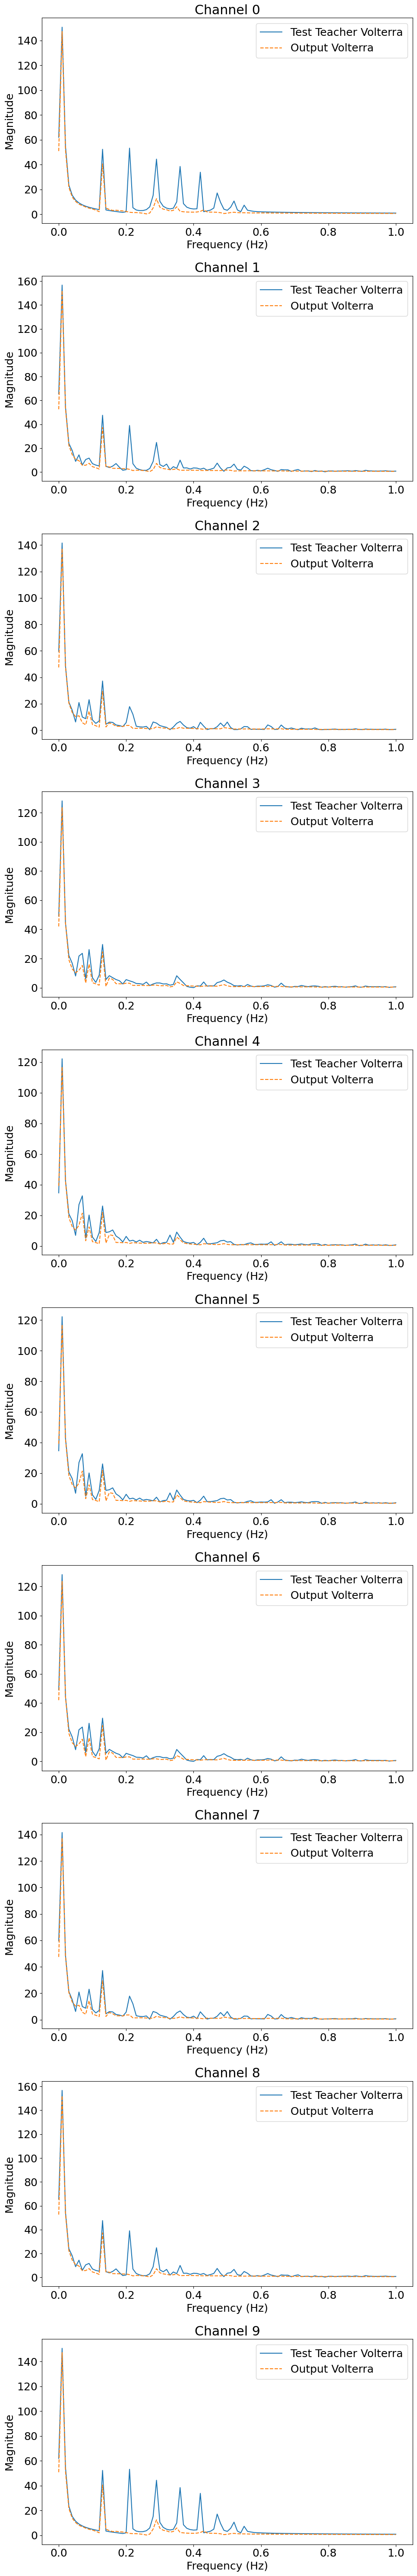

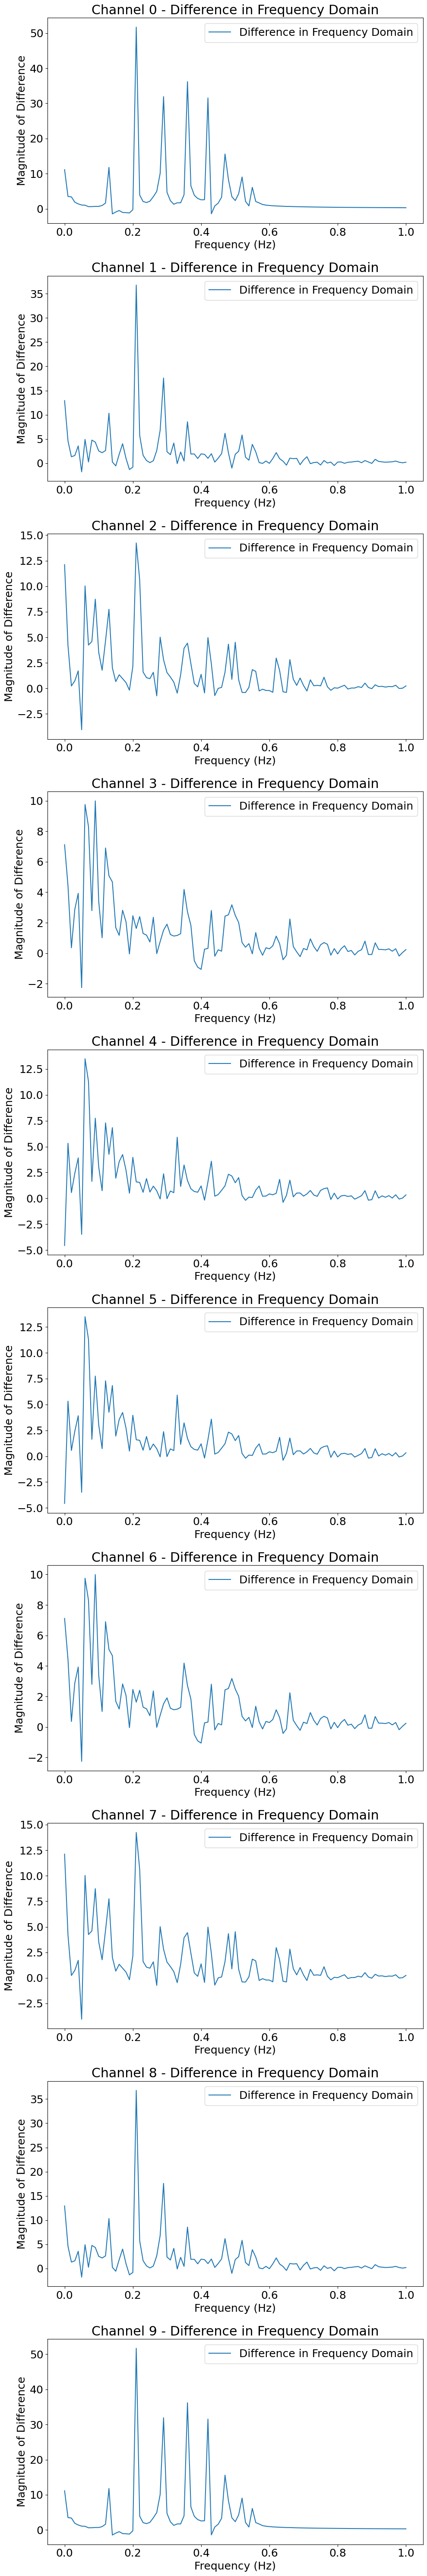

In [6]:
# Fourier transform of the target and output signals to check if they have similar frequency components
from scipy.fft import rfft, rfftfreq

# Apply rfft along the time axis (axis=0) for 2D arrays
test_teacher_volt_freq = rfft(test_teacher_volt, axis=0)
output_volt_freq = rfft(output_volt, axis=0)

# Get the correct length after FFT
fft_length = test_teacher_volt_freq.shape[0]
frequencies = rfftfreq(2 * (fft_length - 1), d=delta_t) if fft_length > 1 else rfftfreq(fft_length, d=delta_t)

print(f"Frequencies shape: {frequencies.shape}")
print(f"Test teacher Volterra frequency shape: {test_teacher_volt_freq.shape}")
print(f"Output Volterra frequency shape: {output_volt_freq.shape}")

zoom_freq = 1
zoom_idx = frequencies <= zoom_freq

# Plot the Fourier transforms for all channels - take magnitude across all channels
n_channels = test_teacher_volt_freq.shape[1]
fig, axs = plt.subplots(n_channels, 1, figsize=(10, 6 * n_channels))
for i in range(n_channels):
    axs[i].plot(frequencies[zoom_idx], np.abs(test_teacher_volt_freq[zoom_idx, i]), label='Test Teacher Volterra')
    axs[i].plot(frequencies[zoom_idx], np.abs(output_volt_freq[zoom_idx, i]), label='Output Volterra', linestyle='dashed')
    axs[i].set_title(f'Channel {i}')
    axs[i].set_xlabel('Frequency (Hz)')
    axs[i].set_ylabel('Magnitude')
    axs[i].legend()
plt.tight_layout()
# plt.savefig(f"images/{SYSTEM}_volt_freq.pdf")

#plot difference between test teacher and output in frequency domain
fig, axs = plt.subplots(n_channels, 1, figsize=(10, 6 * n_channels))
for i in range(n_channels): 
    axs[i].plot(frequencies[zoom_idx], np.abs(test_teacher_volt_freq[zoom_idx, i]) - np.abs(output_volt_freq[zoom_idx, i]), label='Difference in Frequency Domain')
    axs[i].set_title(f'Channel {i} - Difference in Frequency Domain')
    axs[i].set_xlabel('Frequency (Hz)')
    axs[i].set_ylabel('Magnitude of Difference')
    axs[i].legend()
plt.tight_layout()


plt.show()

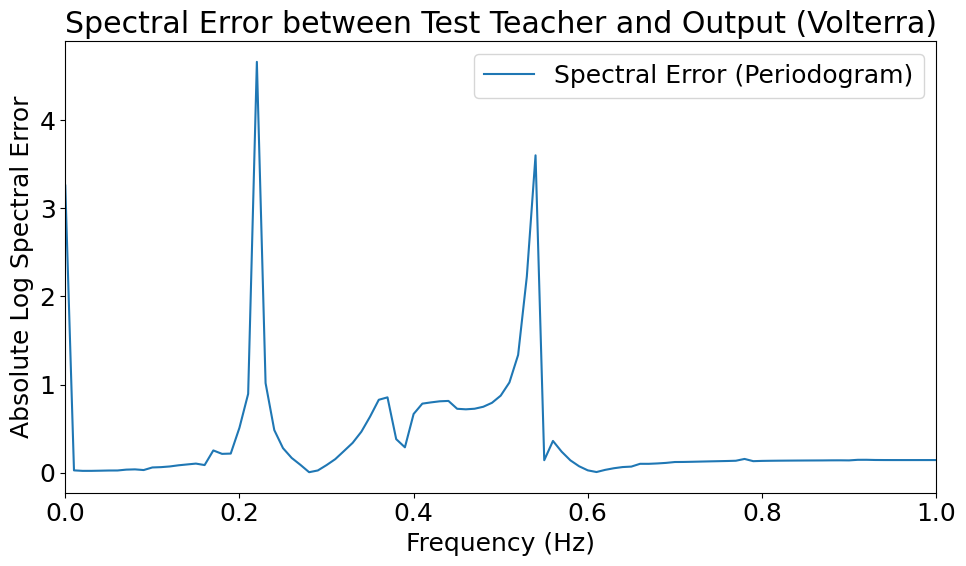

In [5]:
# Compute spectral errors from PSD of the signals using periodogram and Welch's method
from scipy.signal import periodogram, welch
frequencies_periodogram, psd_test_teacher_volt = periodogram(test_teacher_volt[:, 0], fs=1/delta_t)
_, psd_output_volt = periodogram(output_volt[:, 0], fs=1/delta_t)

# Compute errors in spectral density

spectral_error_periodogram = np.abs(np.log(psd_test_teacher_volt)- np.log(psd_output_volt))

# Plot the spectral errors vs frequency
plt.figure(figsize=(10, 6))
plt.plot(frequencies_periodogram, spectral_error_periodogram, label='Spectral Error (Periodogram)')
plt.title('Spectral Error between Test Teacher and Output (Volterra)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Absolute Log Spectral Error')
plt.xlim(0, zoom_freq)
plt.legend()
plt.tight_layout()

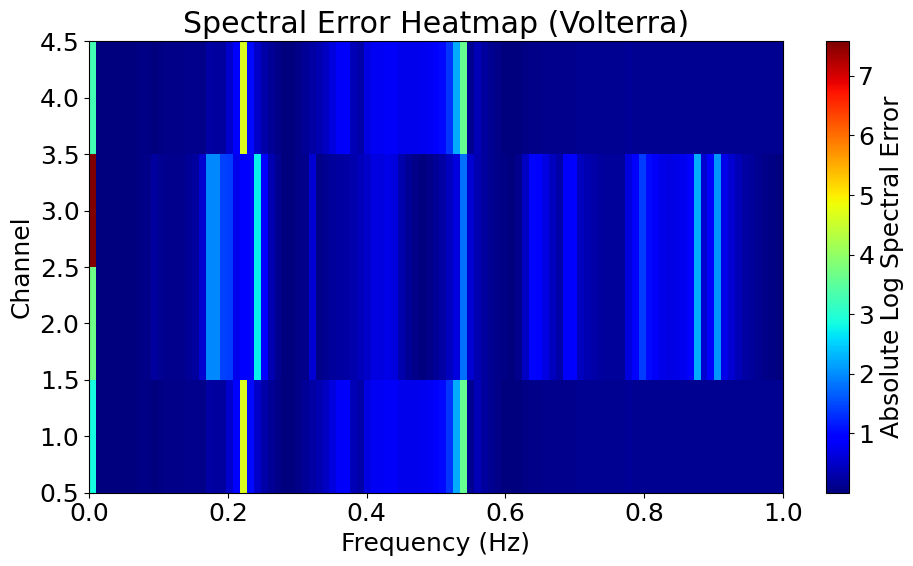

In [6]:
# heatmap of spectral error vs frequency and channel
spectral_error_matrix = np.zeros((len(frequencies_periodogram), n_channels))
for i in range(n_channels):
    _, psd_test_teacher_volt_channel = periodogram(test_teacher_volt[:, i], fs=1/delta_t)
    _, psd_output_volt_channel = periodogram(output_volt[:, i], fs=1/delta_t)
    spectral_error_matrix[:, i] = np.abs(np.log(psd_test_teacher_volt_channel) - np.log(psd_output_volt_channel))
plt.figure(figsize=(10, 6))
plt.imshow(spectral_error_matrix[zoom_idx, :].T, aspect='auto', extent=[frequencies_periodogram[zoom_idx][0], frequencies_periodogram[zoom_idx][-1], 0.5, n_channels + 0.5], cmap='jet')
plt.colorbar(label='Absolute Log Spectral Error')
plt.title('Spectral Error Heatmap (Volterra)')
plt.ylabel('Channel')
plt.xlabel('Frequency (Hz)')
plt.tight_layout()
plt.show()

In [7]:
# Tune hyperparameters around the best values to see if we can improve the results

log_ld_range = 1 - np.logspace(np.log10(1-ld_coef) - 2.0, np.log10(1-ld_coef) + 2.0, num=41)
log_tau_range = np.logspace(np.log10(tau_coef) - 2.0, np.log10(tau_coef) + 2.0, num=41)
log_reg_range = np.logspace(np.log10(reg_best) - 2.0, np.log10(reg_best) + 2.0, num=41)

psd_frequency_test_teacher_volt = np.abs(test_teacher_volt_freq)**2 # (D, F)

mse_ld = []
spectral_error_freq_ld = []

for ld in log_ld_range:
    print(f"Running Volterra with ld_coef: {ld}")
    volt = Volterra(ld, tau_coef, reg_best, washout, selected_index)
    output_volt = volt.Train(train_input_volt, train_teacher_volt).PathContinue(train_teacher_volt[-1], test_teacher_volt.shape[0])
    mse_volt = calculate_mse(test_teacher_volt, output_volt, shift_volt, scale_volt)
    print(f"MSE for ld_coef {ld}: {mse_volt}")
    mse_ld.append(mse_volt)
    # Fourier transform of the output signal to check if they have similar frequency components
    output_volt_freq = rfft(output_volt, axis=0)
    # Power spectral density error in the selected frequency range
    psd_frequency_output_volt = np.abs(output_volt_freq)**2 # (D, F)

    spectral_error_freq = np.abs(np.log(psd_frequency_test_teacher_volt) - np.log(psd_frequency_output_volt))

    spectral_error_freq_ld.append(spectral_error_freq)

mse_tau = []
spectral_error_freq_tau = []

for tau in log_tau_range:
    print(f"Running Volterra with tau_coef: {tau}")
    volt = Volterra(ld_coef, tau, reg_best, washout, selected_index)
    output_volt = volt.Train(train_input_volt, train_teacher_volt).PathContinue(train_teacher_volt[-1], test_teacher_volt.shape[0])
    mse_volt = calculate_mse(test_teacher_volt, output_volt, shift_volt, scale_volt)
    print(f"MSE for tau_coef {tau}: {mse_volt}")
    mse_tau.append(mse_volt)
    # Fourier transform of the output signal to check if they have similar frequency components
    output_volt_freq = rfft(output_volt, axis=0)
    # Power spectral density error in the selected frequency range
    psd_frequency_output_volt = np.abs(output_volt_freq)**2 # (D, F)

    spectral_error_freq = np.abs(np.log(psd_frequency_test_teacher_volt) - np.log(psd_frequency_output_volt))

    spectral_error_freq_tau.append(spectral_error_freq)

mse_reg = []
spectral_error_freq_reg = []

for reg in log_reg_range:
    print(f"Running Volterra with reg: {reg}")
    volt = Volterra(ld_coef, tau_coef, reg, washout, selected_index)
    output_volt = volt.Train(train_input_volt, train_teacher_volt).PathContinue(train_teacher_volt[-1], test_teacher_volt.shape[0])
    mse_volt = calculate_mse(test_teacher_volt, output_volt, shift_volt, scale_volt)
    print(f"MSE for reg {reg}: {mse_volt}")
    mse_reg.append(mse_volt)
    # Fourier transform of the output signal to check if they have similar frequency components
    output_volt_freq = rfft(output_volt, axis=0)
    # Power spectral density error in the selected frequency range
    psd_frequency_output_volt = np.abs(output_volt_freq)**2 # (D, F)

    spectral_error_freq = np.abs(np.log(psd_frequency_test_teacher_volt) - np.log(psd_frequency_output_volt))

    spectral_error_freq_reg.append(spectral_error_freq)

with h5py.File(f'results/{SYSTEM}_{dynamics_type}_N{N}_hx{hx}_{STATE}_{real}_vol_spectral_error.h5', 'w') as f:
    f.create_dataset('log_ld_range', data=log_ld_range)
    f.create_dataset('log_tau_range', data=log_tau_range)
    f.create_dataset('log_reg_range', data=log_reg_range)
    f.create_dataset('mse_ld', data=mse_ld)
    f.create_dataset('mse_tau', data=mse_tau)
    f.create_dataset('mse_reg', data=mse_reg)
    f.create_dataset('spectral_error_freq_ld', data=spectral_error_freq_ld)
    f.create_dataset('spectral_error_freq_tau', data=spectral_error_freq_tau)
    f.create_dataset('spectral_error_freq_reg', data=spectral_error_freq_reg)



Running Volterra with ld_coef: 0.9999817665199913
MSE for ld_coef 0.9999817665199913: 152.97679082187892
Running Volterra with ld_coef: 0.9999770454086716
MSE for ld_coef 0.9999770454086716: 105.57444424213067
Running Volterra with ld_coef: 0.9999711018816594
MSE for ld_coef 0.9999711018816594: 71.07209452933552
Running Volterra with ld_coef: 0.999963619424468
MSE for ld_coef 0.999963619424468: 47.07487469629523
Running Volterra with ld_coef: 0.999954199568967
MSE for ld_coef 0.999954199568967: 31.031649418855338
Running Volterra with ld_coef: 0.9999423406735014
MSE for ld_coef 0.9999423406735014: 20.66159284506731
Running Volterra with ld_coef: 0.999927411208644
MSE for ld_coef 0.999927411208644: 14.122725235393943
Running Volterra with ld_coef: 0.9999086161259505
MSE for ld_coef 0.9999086161259505: 10.023774282537907
Running Volterra with ld_coef: 0.9998849545187308
MSE for ld_coef 0.9998849545187308: 7.365093740485924
Running Volterra with ld_coef: 0.9998551663201182
MSE for ld_coef

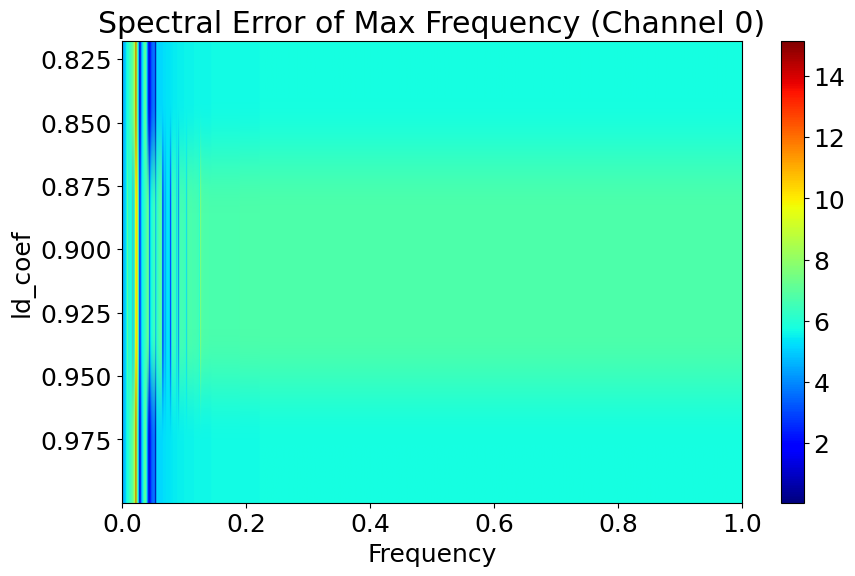

In [8]:
# at channel 0, imshow ld_coef vs frequency with spectral error as the value in the heatmap
plt.figure(figsize=(10, 6))
plt.imshow(spectral_error_freq_ld[4].T, aspect='auto', cmap='jet', extent=[frequencies[zoom_idx][0], frequencies[zoom_idx][-1], log_ld_range[0], log_ld_range[-1]])
plt.colorbar()
plt.xlabel('Frequency')
plt.ylabel('ld_coef')
plt.title('Spectral Error of Max Frequency (Channel 0)')
plt.show()

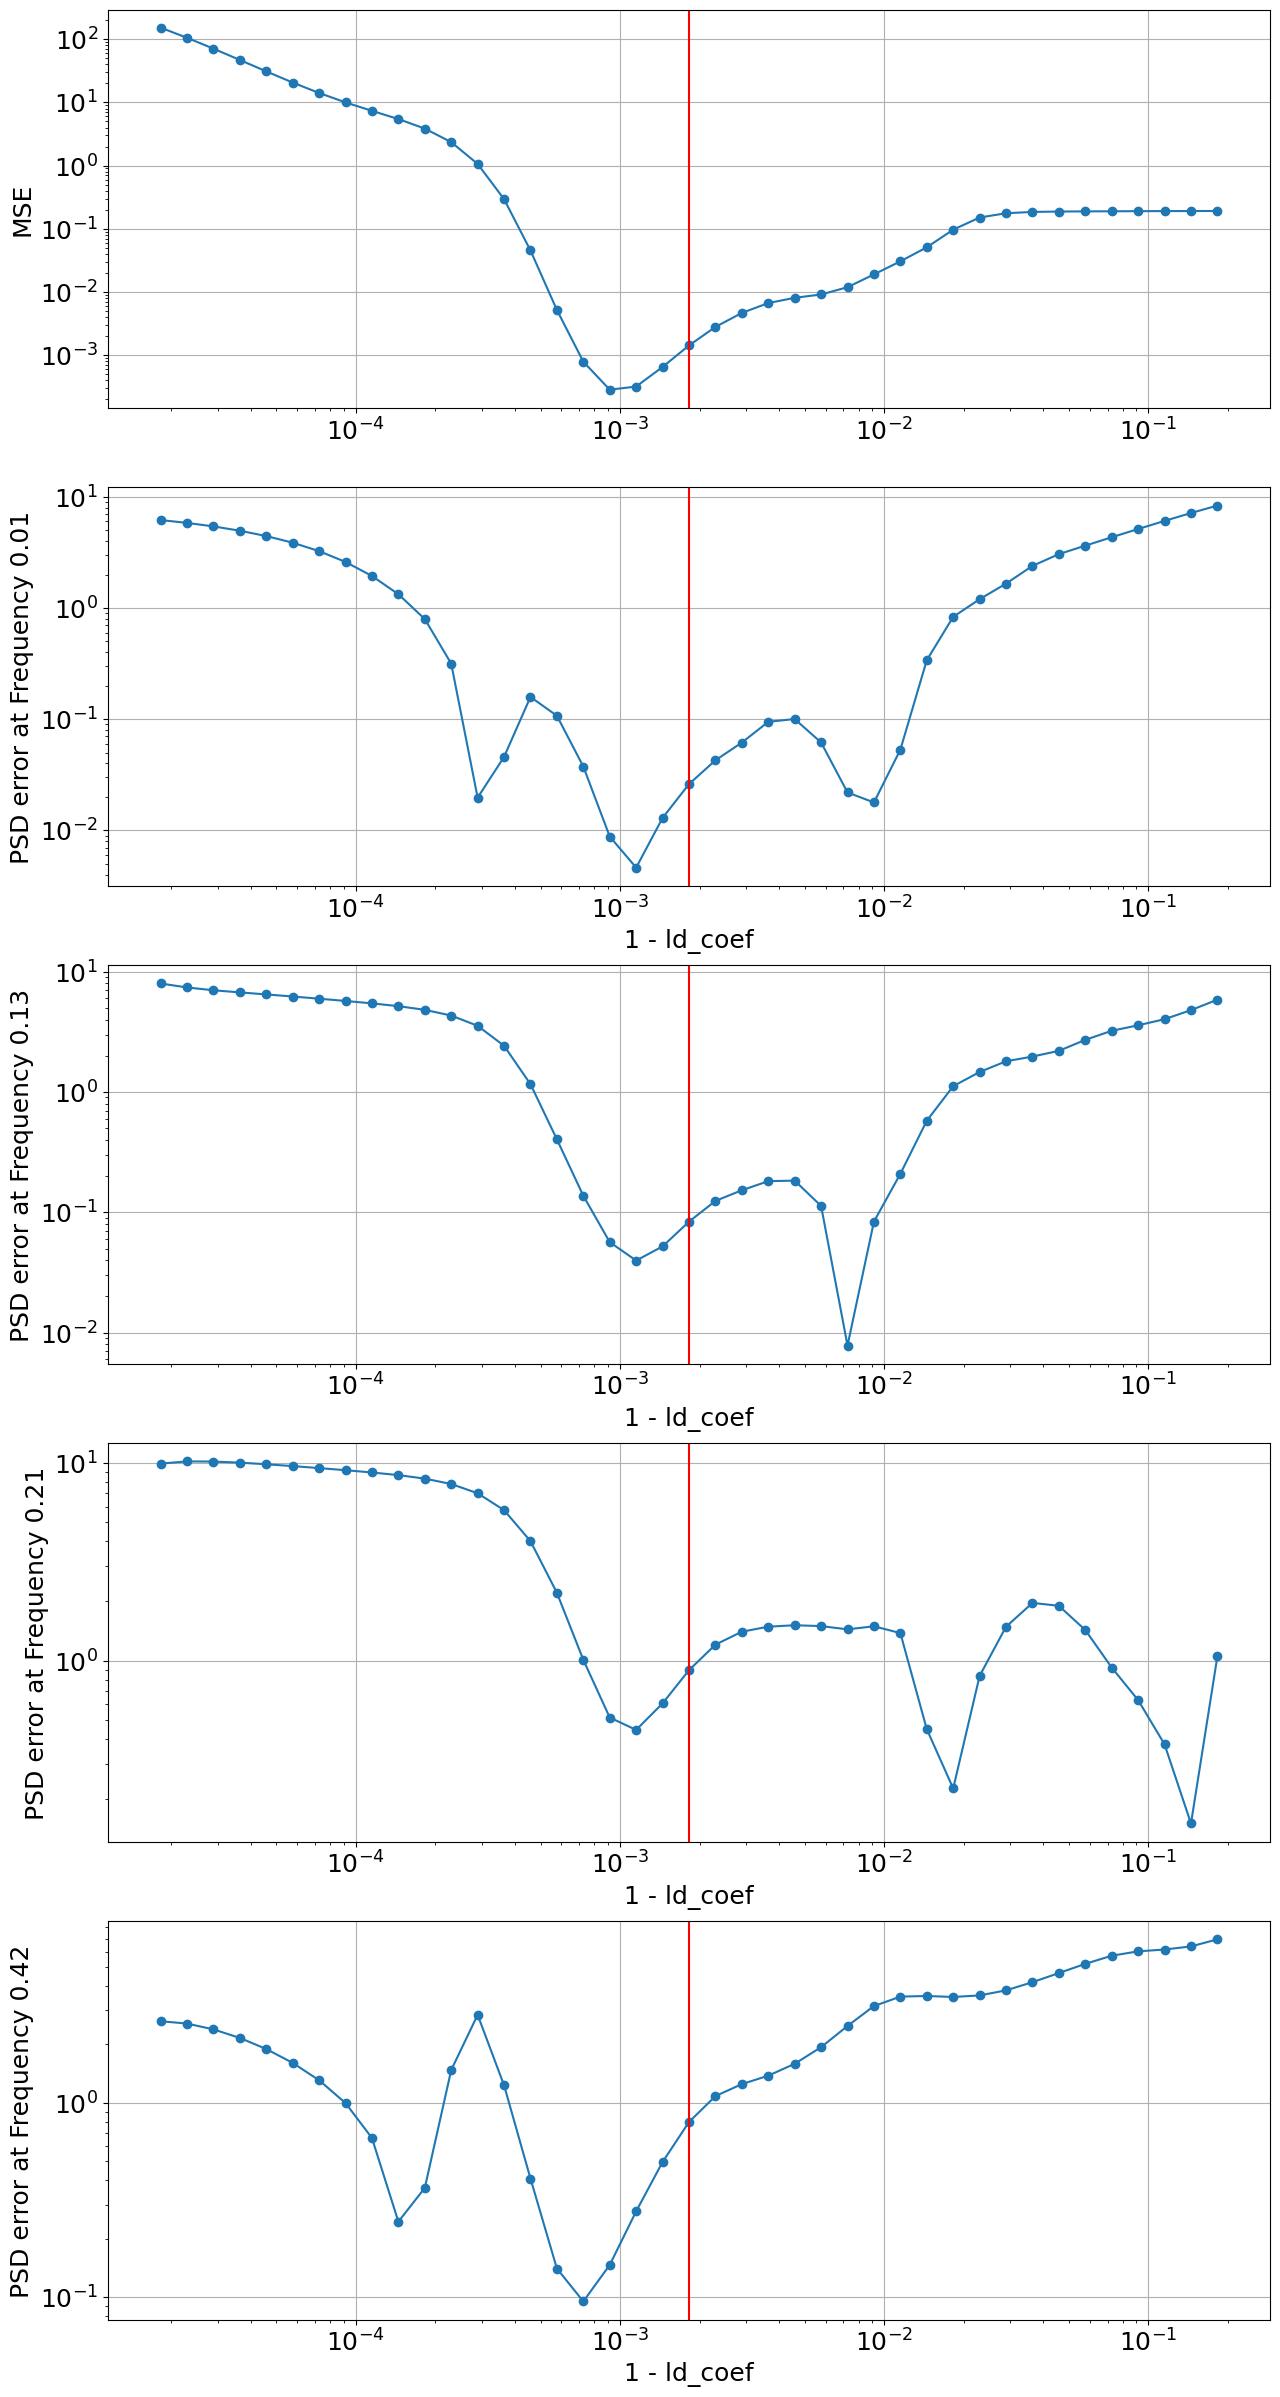

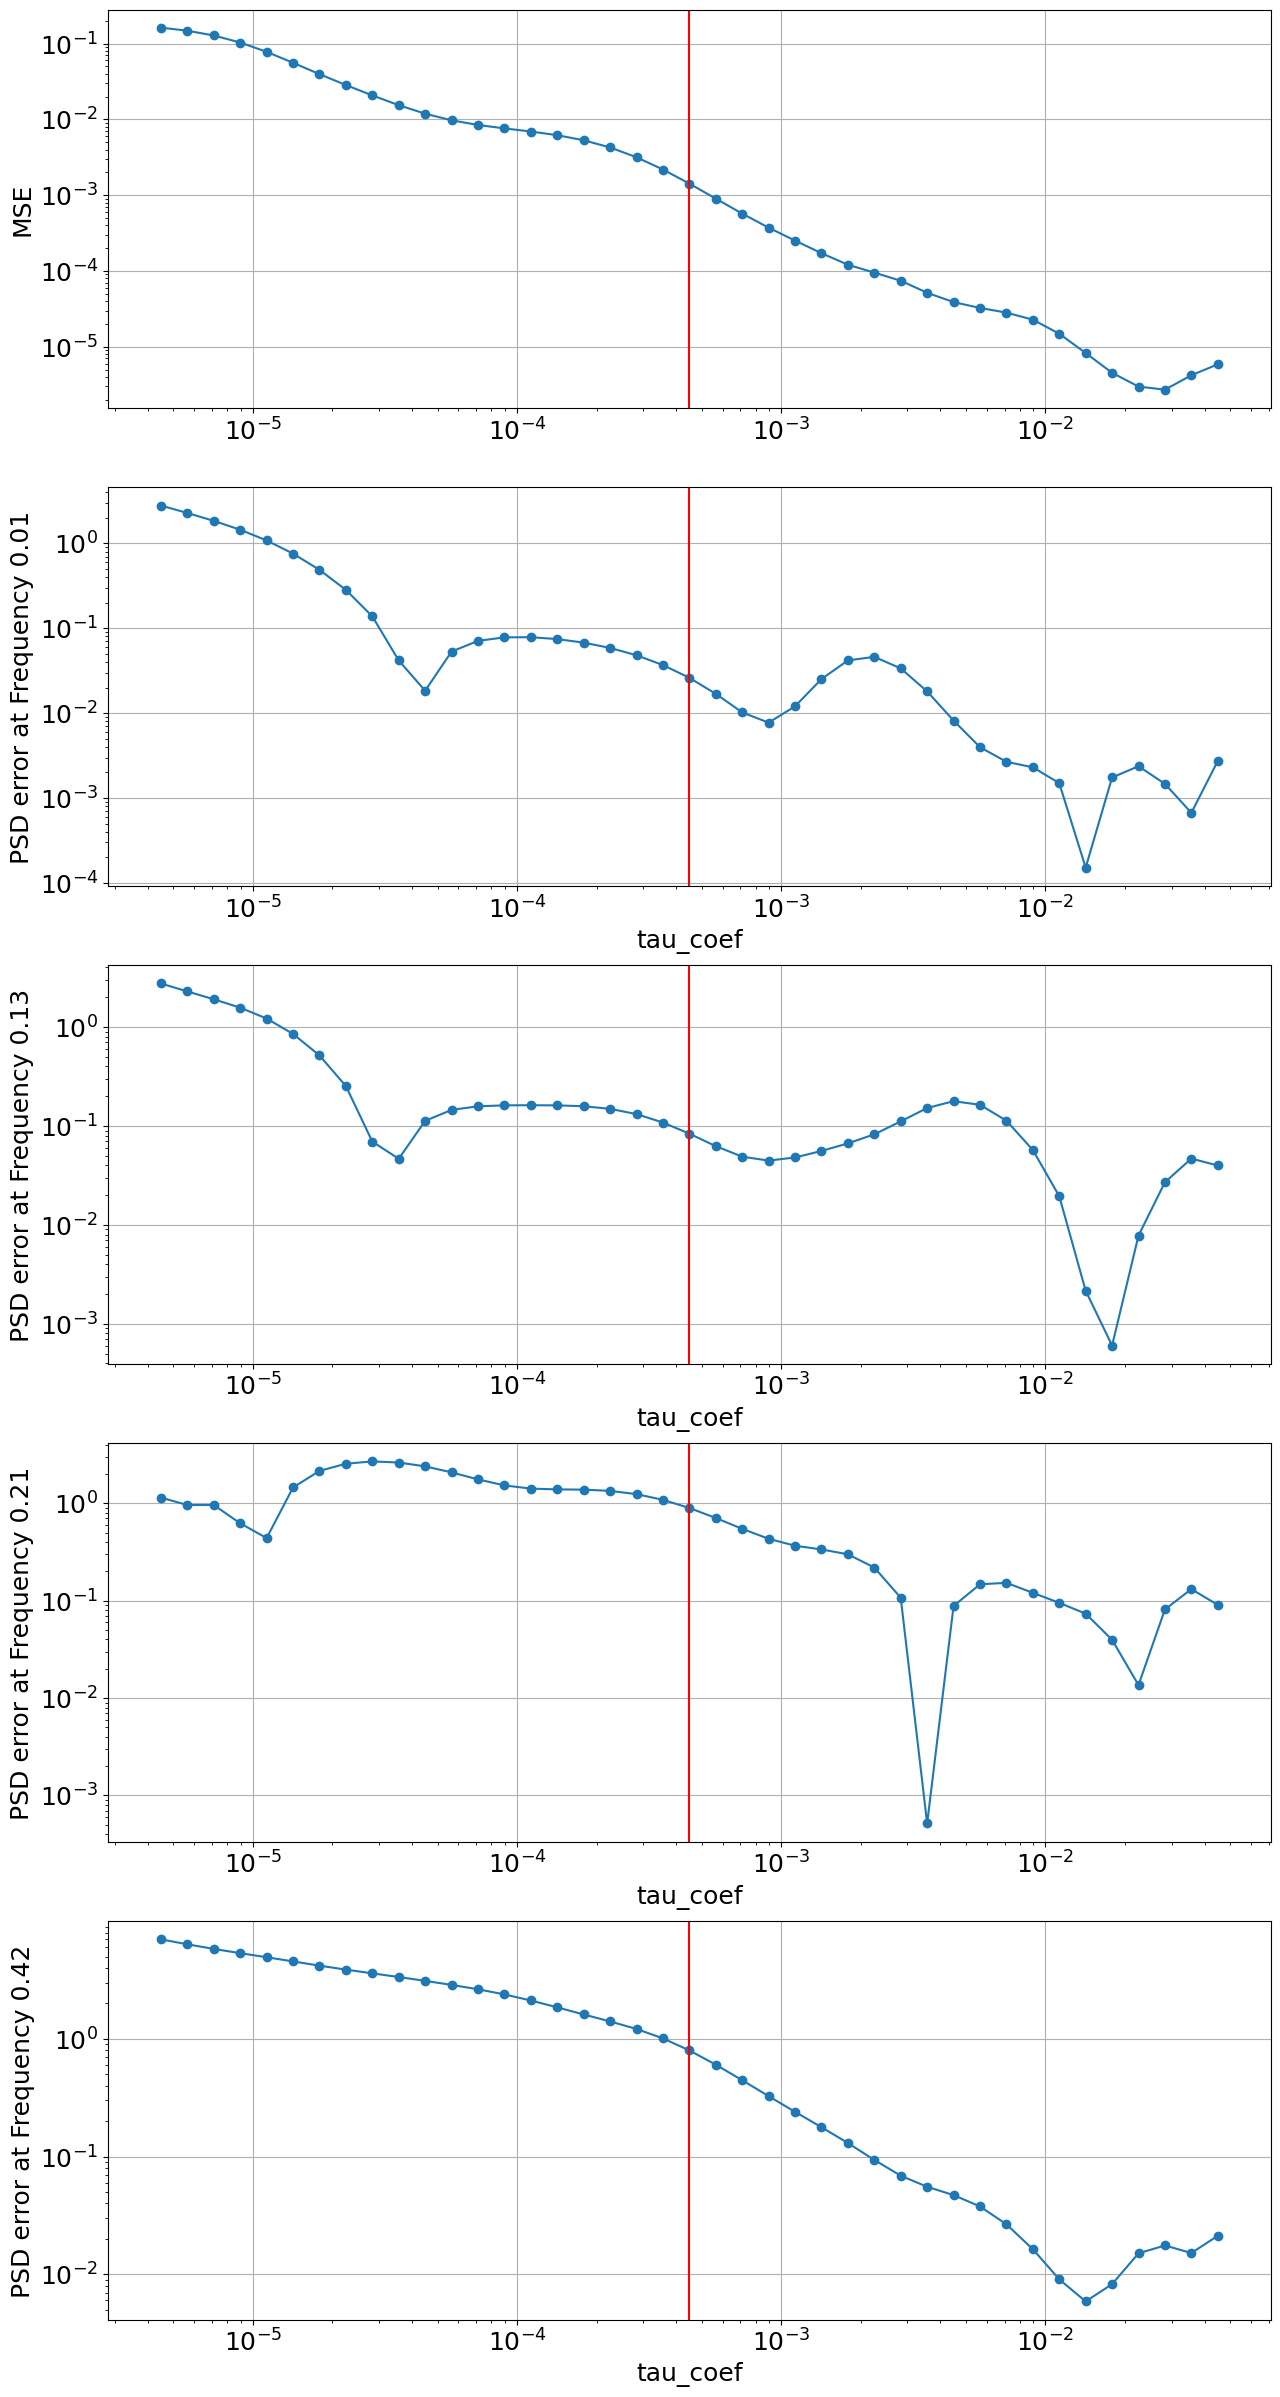

In [12]:
# plot mse and spectral error of selected channel vs ld_coef as subplot

selected_freq_set = [0.01, 0.13 ,0.21,0.42]

selected_channel = 0


fig, axs = plt.subplots(len(selected_freq_set) + 1, 1, figsize=(15, 6 * (len(selected_freq_set) + 1)))
axs[0].plot(1 - log_ld_range, mse_ld, marker='o')
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_ylabel('MSE')
axs[0].axvline(1-ld_coef, c='red')
axs[0].grid()
for i in range(1,len(selected_freq_set) + 1):
    selected_freq = selected_freq_set[i-1]
    selected_freq_idx = np.argmin(np.abs(frequencies - selected_freq))
    axs[i].plot(1 - log_ld_range, [spectral_error_freq_ld[i][selected_freq_idx, selected_channel] for i in range(len(log_ld_range))], marker='o')
    axs[i].set_xscale('log')
    axs[i].set_xlabel('1 - ld_coef')
    axs[i].set_ylabel(f'PSD error at Frequency {selected_freq}')
    axs[i].set_yscale('log')
    axs[i].axvline(1-ld_coef, c='red')
    # axs[1].set_title(f'Spectral Error at {selected_freq} Hz vs ld_coef (Channel {selected_channel})')
    axs[i].grid()

fig, axs = plt.subplots(len(selected_freq_set) + 1, 1, figsize=(15, 6 * (len(selected_freq_set) + 1)))
axs[0].plot(log_tau_range, mse_tau, marker='o')
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_ylabel('MSE')
axs[0].axvline(tau_coef, c='red')
axs[0].grid()
for i in range(1,len(selected_freq_set) + 1):
    selected_freq = selected_freq_set[i-1]
    selected_freq_idx = np.argmin(np.abs(frequencies - selected_freq))
    axs[i].plot(log_tau_range, [spectral_error_freq_tau[i][selected_freq_idx, selected_channel] for i in range(len(log_tau_range))], marker='o')
    axs[i].set_xscale('log')
    axs[i].set_xlabel('tau_coef')
    axs[i].set_ylabel(f'PSD error at Frequency {selected_freq}')
    axs[i].set_yscale('log')
    axs[i].axvline(tau_coef, c='red')
    # axs[1].set_title(f'Spectral Error at {selected_freq} Hz vs ld_coef (Channel {selected_channel})')
    axs[i].grid()
plt.show()


shape (1001, 4)


Text(0.5, 0, 'Frequency')

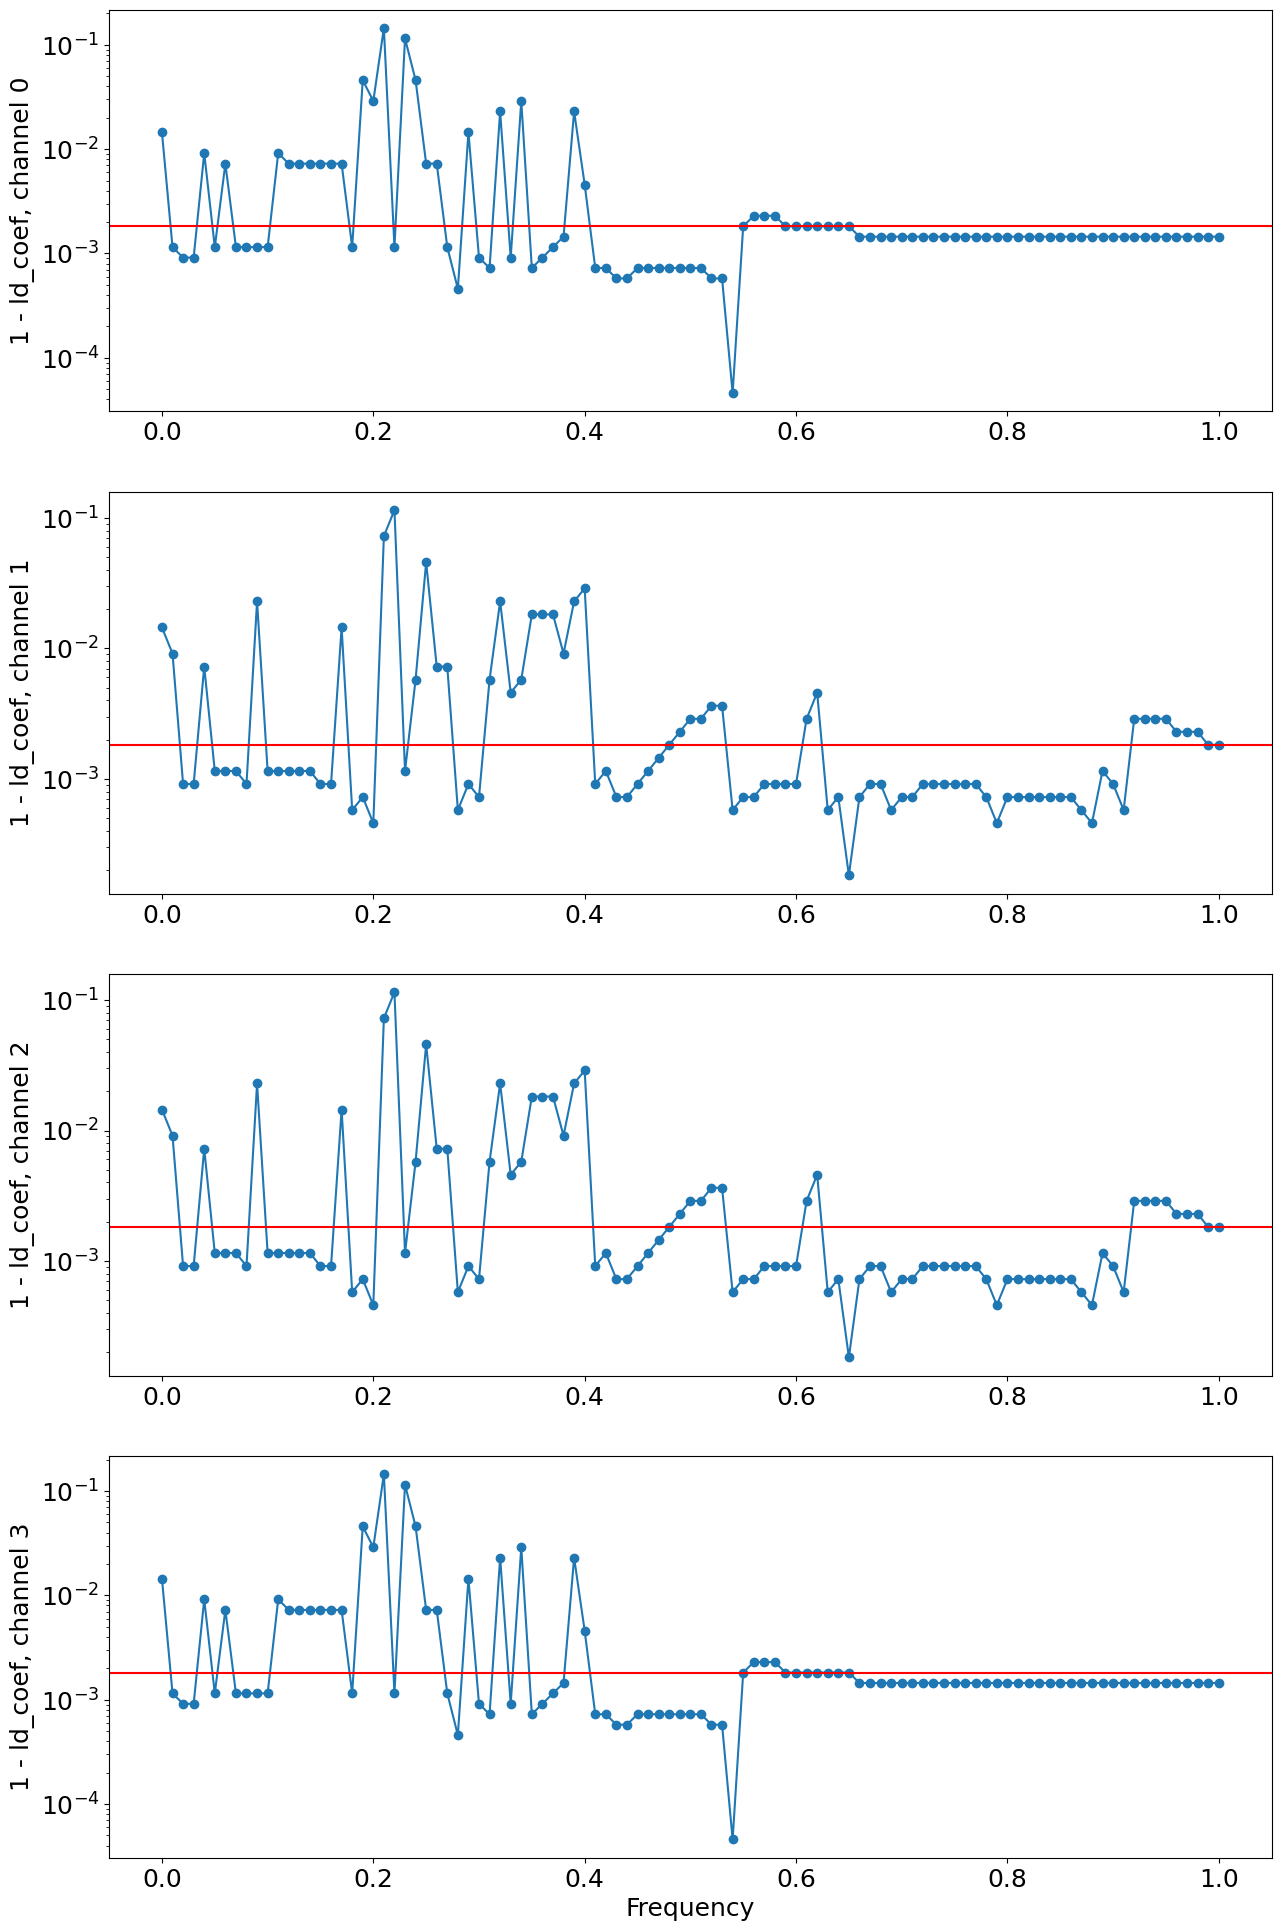

In [ ]:
# Plot min PSD error vs 1-ld_coef
spectral_error_freq_ld = np.array(spectral_error_freq_ld) # (ld,F,D)

optimal_ld_indices = np.argmin(spectral_error_freq_ld, axis=0)

opt_ld_PSD_error = 1 - log_ld_range[optimal_ld_indices]

print(f'shape {opt_ld_PSD_error.shape}')

fig, axs = plt.subplots(n_channels,1,figsize=(15, 6 * n_channels))
for i in range(n_channels):
    axs[i].plot(frequencies[zoom_idx], opt_ld_PSD_error[zoom_idx, i], marker='o')
    axs[i].set_yscale('log')
    axs[i].set_ylabel(f'1 - ld_coef, channel {i}')
    axs[i].axhline(1-ld_coef, c='red')
axs[-1].set_xlabel('Frequency')

shape (1001, 4)


Text(0.5, 0, 'Frequency')

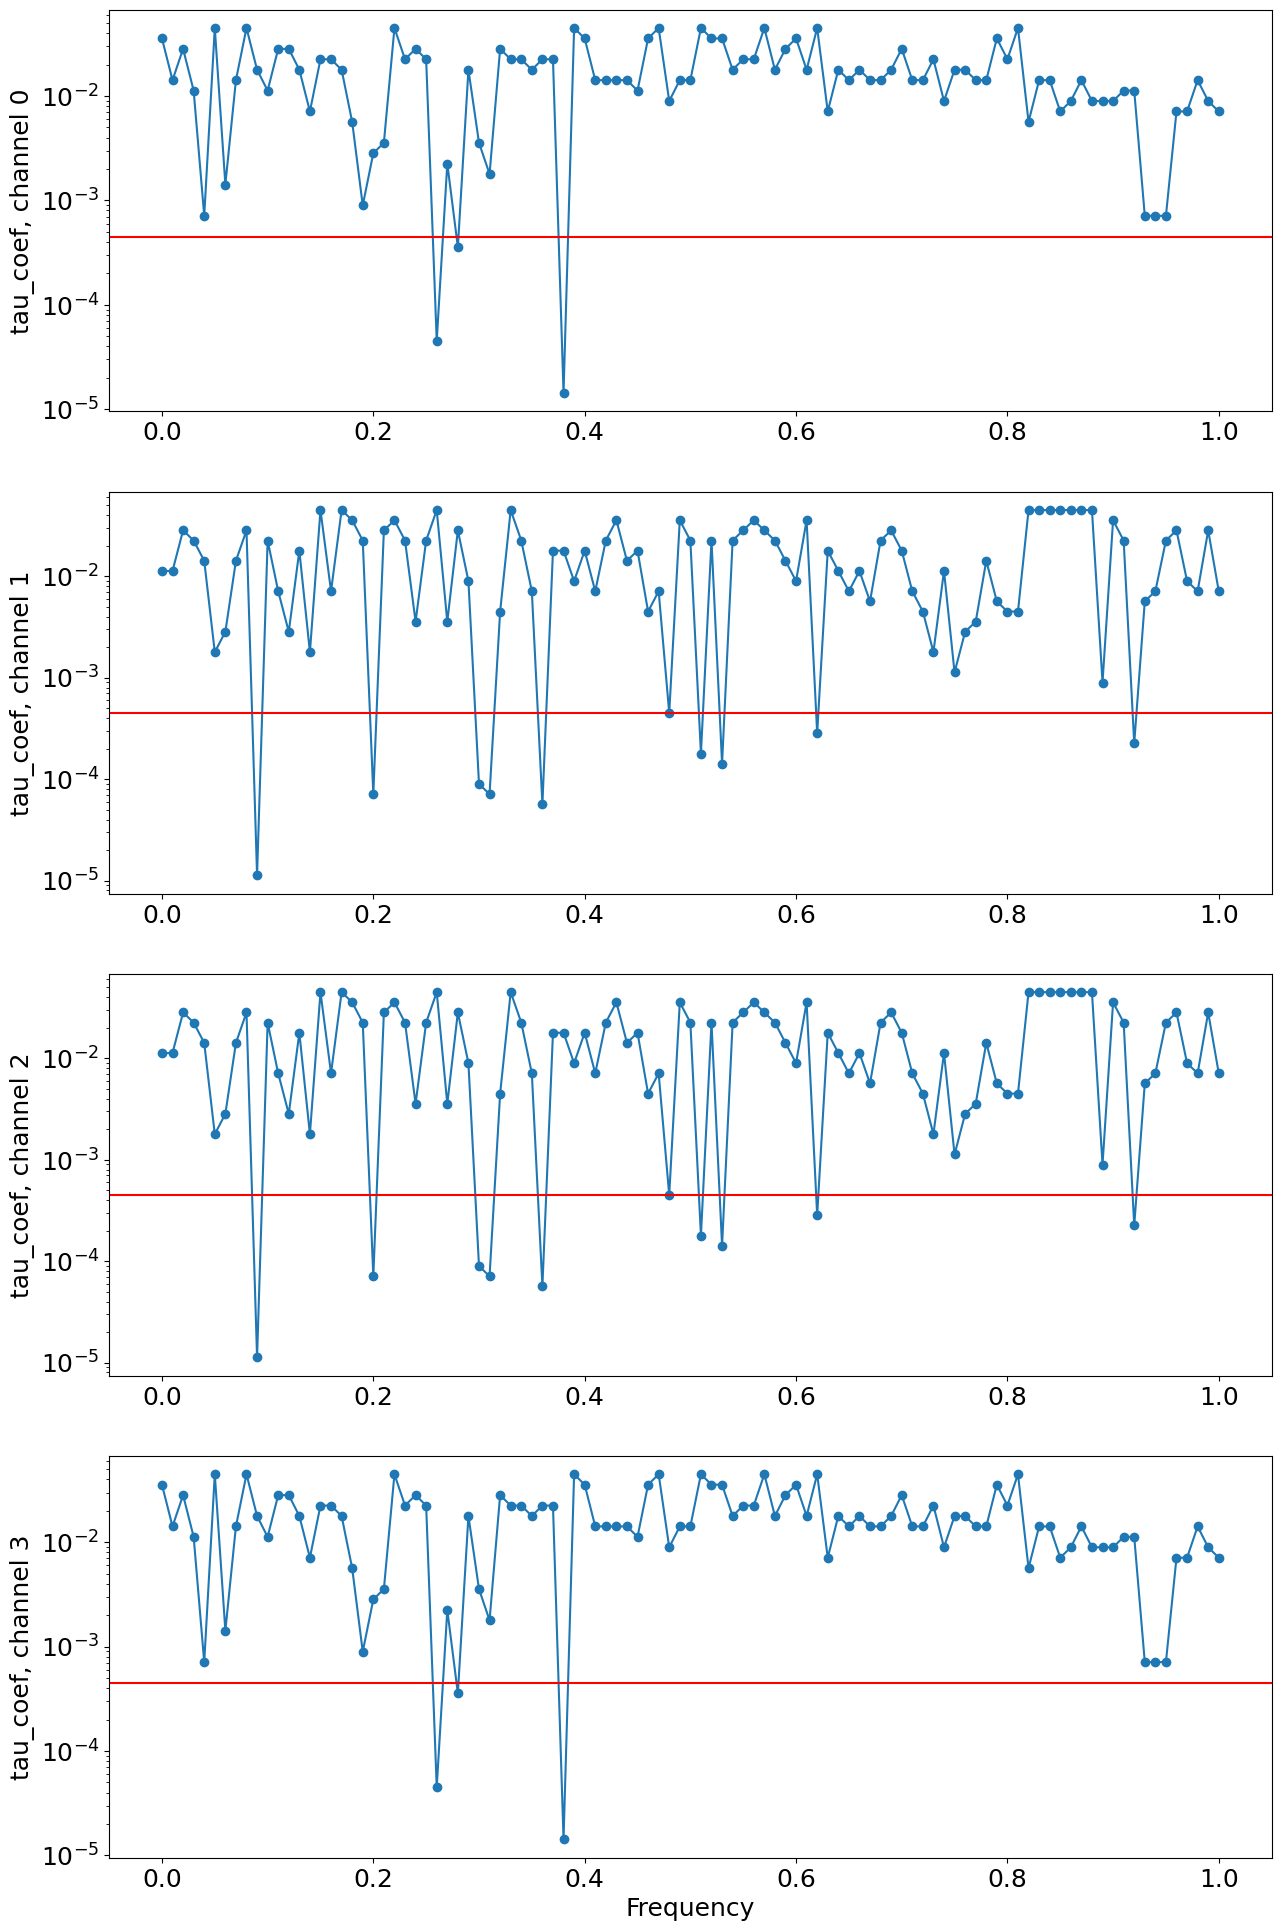

In [11]:
# Plot min PSD error vs tau_coef
spectral_error_freq_tau = np.array(spectral_error_freq_tau) # (ld,F,D)

optimal_tau_indices = np.argmin(spectral_error_freq_tau, axis=0)

opt_tau_PSD_error = log_tau_range[optimal_tau_indices]

print(f'shape {opt_tau_PSD_error.shape}')

fig, axs = plt.subplots(n_channels,1,figsize=(15, 6 * n_channels))
for i in range(n_channels):
    axs[i].plot(frequencies[zoom_idx], opt_tau_PSD_error[zoom_idx, i], marker='o')
    axs[i].set_yscale('log')
    axs[i].set_ylabel(f'tau_coef, channel {i}')
    axs[i].axhline(tau_coef, c='red')
axs[-1].set_xlabel('Frequency')

In [ ]:
# # Tune hyperparameters around the best values to see if we can improve the results
# import numpy as np
# from estimators.volt_funcs_mod import Volterra
# from utils.normalisation import normalise_arrays
# from utils.errors import calculate_mse
# import h5py
# from itertools import product
# import multiprocessing


# def get_volterra_PSD(parameters):
#     normalisation_output, test_parameters = parameters
#     train_input_volt, train_teacher_volt, test_input_volt, test_teacher_volt = normalisation_output[0]
#     shift_volt, scale_volt = normalisation_output[1], normalisation_output[2]
#     volt = Volterra(test_parameters)
#     output_volt = volt.Train(train_input_volt, train_teacher_volt).PathContinue(train_teacher_volt[-1], test_teacher_volt.shape[0])
#     mse_volt = calculate_mse(test_teacher_volt, output_volt, shift_volt, scale_volt)
#     # Fourier transform of the output signal to check if they have similar frequency components
#     output_volt_freq = rfft(output_volt, axis=0)
#     # Power spectral density error in the selected frequency range
#     psd_frequency_output_volt = np.abs(output_volt_freq)**2 # (D, F)
#     test_teacher_volt_freq = rfft(test_teacher_volt, axis=0)
#     psd_frequency_test_teacher_volt = np.abs(test_teacher_volt_freq)**2
#     spectral_error_freq = np.abs(np.log(psd_frequency_test_teacher_volt) - np.log(psd_frequency_output_volt))
#     return mse_volt, spectral_error_freq

# if __name__ == '__main__':

#     SYSTEM = 'TFIM'
#     STATE = 'Neel'
#     N = 4
#     hx = 0.8
#     real = 0
#     dynamics_type = 'sz_all' # 'sz_dynamics', 'sz_all', 'szsz_all'

#     # Load data from npy files
#     data_rawraw = np.load(f'data/{SYSTEM}_{dynamics_type}_N{N}_hx{hx}_{STATE}_{real}.npy')
#     if data_rawraw.ndim == 1:
#         data_raw = np.expand_dims(data_rawraw, axis=1)
#         ndim = 1
#     else:
#         data_raw = data_rawraw.T
#         ndim = data_raw.shape[1]
#     # entropy_dynamics = np.load(f'data/{SYSTEM}_sent_N{N}_hx{hx}_real{real}.npy')
#     tgrid_raw = np.load(f'data/{SYSTEM}_tgrid.npy')

#     delta_t = tgrid_raw[1] - tgrid_raw[0]

#     # Define training and washout size
#     t_train = 300
#     ntrain = int(t_train / delta_t)
#     t_wash = 50
#     wash = int(t_wash / delta_t)
#     data = data_raw[wash:] # Ensure data is long enough for training + washout
#     tgrid = tgrid_raw[wash:]
#     washout = 0

#     # Define input hyperparameters for Volterra
#     ld_coef, tau_coef, reg_best, washout, selected_index = 0.9981766519991315,0.00044892512582186077,0.001, 0, [N//2]

#     # Construct training input and teacher, testing input and teacher
#     training_input_orig = data[0:ntrain-1] 
#     training_teacher_orig = data[1:ntrain]

#     ndata = len(data)
#     # ntrain = 500
#     t_test = 100
#     ntest = int(t_test / delta_t)

#     # Max valid prediction time is about above 10. Round to 11 for error range.
#     t_err = 50
#     err_range = int(t_err / delta_t)
#     # Construct training input and teacher, testing input and teacher
#     training_input_orig = data[0:ntrain-1] 
#     training_teacher_orig = data[1:ntrain]
#     testing_input_orig = data[ntrain-1:ntrain+ntest-1]
#     testing_teacher_orig = data[ntrain:ntrain+ntest]
#     x_values = tgrid[ntrain:ntrain+ntest]

#     # Normalise the arrays for Volterra
#     normalisation_output = normalise_arrays([training_input_orig, training_teacher_orig, testing_input_orig, testing_teacher_orig], norm_type="ScaleL2Shift")

#     num_processes = 10

#     log_ld_range = 1 - np.logspace(np.log10(1-ld_coef) - 2.0, np.log10(1-ld_coef) + 2.0, num=5)
#     log_tau_range = np.logspace(np.log10(tau_coef) - 2.0, np.log10(tau_coef) + 2.0, num=5)
#     log_reg_range = np.logspace(np.log10(reg_best) - 2.0, np.log10(reg_best) + 2.0, num=5)

#     # psd_frequency_test_teacher_volt = np.abs(test_teacher_volt_freq)**2 # (D, F)

#     params_range = [log_ld_range,log_tau_range,log_reg_range]
#     grid_shape = (len(log_ld_range), len(log_tau_range), len(log_reg_range))

#     mse_ld = []
#     spectral_error_freq_ld = []

#     parameter_combinations = list(product(*params_range))

#     combinations = []
#     for param_choice in parameter_combinations:
#         input_com = (normalisation_output,(*param_choice, washout, selected_index))
#         combinations.append(input_com)
    
#     mse_flat = []
#     spectral_error_flat = []

#     pool = multiprocessing.Pool(processes=num_processes)

#     # 1. Set up tracking variables
#     total_tasks = len(combinations)
#     completed = 0

#     # 1. CRITICAL: Use imap instead of imap_unordered to preserve order
#     # chunksize can be increased (e.g., to 10 or 50) to reduce IPC overhead since tasks are small
#     for mse_volt, spectral_error_freq in pool.imap(get_volterra_PSD, combinations, chunksize=10):
#         mse_flat.append(mse_volt)
#         spectral_error_flat.append(spectral_error_freq)
#         completed += 1
#         percentage = (completed / total_tasks) * 100
        
#         # \r forces the cursor back to the start of the line. 
#         # flush=True forces the terminal to update immediately.
#         print(f"\rProgress: {completed}/{total_tasks} completed ({percentage:.1f}%)", end="", flush=True)
        
#     pool.close()
#     pool.join()

#     print("\nProcessing complete. Saving to HDF5...")

#     # 2. Reshape the flat lists into multi-dimensional arrays based on the parameter grid
#     mse_grid = np.array(mse_flat).reshape(grid_shape)
    
#     # spectral_error_freq likely has dimensions (D, F). 
#     # We unpack its inherent shape dynamically to append to our grid shape.
#     # Final shape will be (41, 41, 41, D, F)
#     spectral_inner_shape = spectral_error_flat[0].shape
#     spectral_error_grid = np.array(spectral_error_flat).reshape(*grid_shape, *spectral_inner_shape)

#     # 3. Save to HDF5
#     file_path = f'results/{SYSTEM}_{dynamics_type}_N{N}_hx{hx}_{STATE}_{real}_vol_spectral_error.h5'
#     with h5py.File(file_path, 'w') as f:
#         # Save the axes
#         f.create_dataset('log_ld_range', data=log_ld_range)
#         f.create_dataset('log_tau_range', data=log_tau_range)
#         f.create_dataset('log_reg_range', data=log_reg_range)
        
#         # Save the corresponding mapped results
#         f.create_dataset('mse_grid', data=mse_grid)
#         f.create_dataset('spectral_error_grid', data=spectral_error_grid)
        
#     print(f"Data saved successfully. MSE Grid shape: {mse_grid.shape}")
